<a href="https://colab.research.google.com/github/phornkanok00/GE338-Data-Science/blob/main/Lab3_Machine_learning/Lab3_Machine_Modeling_6606614763.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!pip install geemap

In [49]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='ee-phornkanok')

In [65]:
# =========================
# Setup + Data + Display
# =========================
import ee
import geemap
Map = geemap.Map()

# =========================
# ROI
# =========================
provinces = ee.FeatureCollection("FAO/GAUL/2015/level1")

roi = provinces \
    .filter(ee.Filter.eq('ADM0_NAME', 'Thailand')) \
    .filter(ee.Filter.eq('ADM1_NAME', 'Chanthaburi'))

Map.centerObject(roi, 8)
Map.addLayer(roi, {'color': 'red'}, 'ROI')

# =========================
# Sentinel-2
# =========================
s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(roi) \
    .filterDate('2024-01-01', '2024-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .select(['B2','B3','B4','B8','B11']) \
    .median() \
    .clip(roi)

# True Color
Map.addLayer(s2, {
    'bands': ['B4','B3','B2'],
    'min': 0,
    'max': 3000
}, 'True Color')

# =========================
# Indices
# =========================
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = s2.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndbi = s2.normalizedDifference(['B11', 'B8']).rename('NDBI')

image = s2.addBands([ndvi, ndwi, ndbi])

bands = ['B2','B3','B4','B8','B11','NDVI','NDWI','NDBI']

# แสดง indices
Map.addLayer(ndvi, {'min':-1,'max':1,'palette':['blue','white','green']}, 'NDVI')
Map.addLayer(ndwi, {'min':-1,'max':1,'palette':['brown','white','blue']}, 'NDWI')
Map.addLayer(ndbi, {'min':-1,'max':1,'palette':['green','white','red']}, 'NDBI')

# =========================
# ESA WorldCover
# =========================
lc = ee.Image("ESA/WorldCover/v200/2021").clip(roi)

Map.addLayer(lc, {}, 'ESA Original')

# =========================
# Remap (5 classes)
# =========================
lc_remap = lc.remap(
    [30, 40,   10, 95,   50,   80,   20, 60, 70, 90, 100],
    [1,  1,    2,  2,    3,    4,    5,  5,  5,  5,  5]
).rename('class')

Map.addLayer(lc_remap, {
    'min':1,
    'max':5,
    'palette':['yellow','green','red','blue','gray']
}, 'ESA Remap (5 classes)')

Map


Map(center=[12.87622230139344, 102.13202401595468], controls=(WidgetControl(options=['position', 'transparent_…

In [67]:
# =========================
# Task 1: Sampling + Train/Test Split
# =========================
samples = image.addBands(lc_remap).stratifiedSample(
    numPoints=1000,
    classBand='class',
    region=roi,
    scale=10,
    geometries=True
)

# split 80/20
withRandom = samples.randomColumn('random')

train_set = withRandom.filter('random < 0.8')
test_set = withRandom.filter('random >= 0.8')

print('Train size:', train_set.size().getInfo())
print('Test size:', test_set.size().getInfo())

Train size: 4055
Test size: 945


# Algorithm Comparison

*   2.1 Random forest vs Gradient Tree Boost



In [64]:
# =========================
# Task 2: Random Forest 100 ต้น
# =========================

# Train Random Forest 100 trees
rf = ee.Classifier.smileRandomForest(100).train(
    features=train_set,
    classProperty='class',
    inputProperties=bands
)

# Classification
rf_classified = image.select(bands).classify(rf)

# =========================
# สร้าง Map object ใหม่
# =========================
Map_rf100 = geemap.Map()  # Map object ใหม่
Map_rf100.centerObject(roi, 8)

# เพิ่ม layer classification
Map_rf100.addLayer(rf_classified, {
    'min': 1,
    'max': 5,
    'palette': ['yellow','green','red','blue','gray']
}, 'RF Classification 100')

# แสดง Map
Map_rf100

Map(center=[12.87622230139344, 102.13202401595468], controls=(WidgetControl(options=['position', 'transparent_…

In [63]:
# =========================
# Task 2: Random Forest 300 ต้น
# =========================

# Train RF 300 trees
rf_test2 = ee.Classifier.smileRandomForest(300).train(
    features=train_set,
    classProperty='class',
    inputProperties=bands
)

# Classification
rf_classified_2 = image.select(bands).classify(rf_test2)

# =========================
# สร้าง Map object ใหม่
# =========================
Map_rf300 = geemap.Map()  # สร้าง Map ใหม่
Map_rf300.centerObject(roi, 8)

# เพิ่ม layer classification
Map_rf300.addLayer(rf_classified_2, {
    'min': 1,
    'max': 5,
    'palette': ['yellow','green','red','blue','gray']
}, 'RF Classification 300')

# แสดง Map
Map_rf300

Map(center=[12.87622230139344, 102.13202401595468], controls=(WidgetControl(options=['position', 'transparent_…

In [68]:
# =========================
# Task 2: Gradient Tree Boost
# =========================

# Train Gradient Tree Boost 300 trees
gtb = ee.Classifier.smileGradientTreeBoost(300).train(
    features=train_set,
    classProperty='class',
    inputProperties=bands
)

# Classification
gtb_classified = image.select(bands).classify(gtb)

# =========================
# สร้าง Map object ใหม่
# =========================
Map_gtb = geemap.Map()  # Map object ใหม่
Map_gtb.centerObject(roi, 8)

# เพิ่ม layer classification
Map_gtb.addLayer(gtb_classified, {
    'min': 1,
    'max': 5,
    'palette': ['yellow','green','red','blue','gray']
}, 'GTB Classification')

# แสดง Map
Map_gtb

Map(center=[12.87622230139344, 102.13202401595468], controls=(WidgetControl(options=['position', 'transparent_…

In [55]:
# =========================
# Export GTB Classification to Google Drive
# =========================
task = ee.batch.Export.image.toDrive(
    image=gtb_classified,           # ภาพ classification ที่เราทำ
    description='GTB_Classification',  # ชื่อ task ใน GEE
    folder='GE338',            # โฟลเดอร์ใน Google Drive
    fileNamePrefix='GTB_Classification',  # ชื่อไฟล์ prefix
    scale=10,                        # ระบุ resolution (m/pixel) → ปรับตาม Sentinel-2
    region=roi.geometry(),           # พื้นที่ ROI
    crs='EPSG:32647',                # ระบบพิกัด UTM Zone 47N (ตัวอย่างสำหรับเชียงใหม่)
    maxPixels=1e13                   # จำนวน pixel สูงสุดสำหรับ export
)

# เริ่ม export
task.start()

print("Export task started")

Export task started


# Confusion Matrix

Confusion Matrix :
 [[134  23  27   8  13]
 [ 36 141  10   2   6]
 [ 21   7 152   0  12]
 [  0   0   2 147  29]
 [ 11   8  30  24 102]]
Overall Accuracy: 0.7153439153439154
Kappa: 0.6438259236944979

Producer's Accuracy (Recall) per class:
Class 1: 0.6537
Class 2: 0.7231
Class 3: 0.7917
Class 4: 0.8258
Class 5: 0.5829

User's Accuracy (Precision) per class:
Class 1: 0.6634
Class 2: 0.7877
Class 3: 0.6878
Class 4: 0.8122
Class 5: 0.6296

F1-score per class:
Class 1: 0.6585
Class 2: 0.7540
Class 3: 0.7361
Class 4: 0.8189
Class 5: 0.6053

Macro F1-score: 0.7146
Weighted F1-score: 0.7143


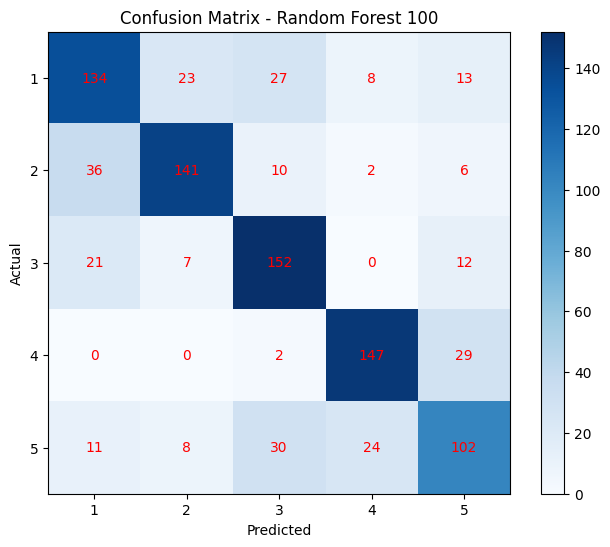

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1) Confusion Matrix
# =========================
rf_test = test_set.classify(rf)
cm = rf_test.errorMatrix('class', 'classification')

# ดึง matrix มาเป็น numpy
conf_matrix = np.array(cm.getInfo())

#  ตัด class 0 (background)
conf_matrix = conf_matrix[1:, 1:]

print('Confusion Matrix :\n', conf_matrix)
print('Overall Accuracy:', cm.accuracy().getInfo())
print('Kappa:', cm.kappa().getInfo())


# =========================
# 2) Producer's & User's Accuracy
# =========================
producers_acc = np.array(cm.producersAccuracy().getInfo()).flatten()[1:]
users_acc = np.array(cm.consumersAccuracy().getInfo()).flatten()[1:]

print("\nProducer's Accuracy (Recall) per class:")
for i, val in enumerate(producers_acc, start=1):
    print(f"Class {i}: {val:.4f}")

print("\nUser's Accuracy (Precision) per class:")
for i, val in enumerate(users_acc, start=1):
    print(f"Class {i}: {val:.4f}")


# =========================
# 3) F1-score per class
# =========================
f1_scores = []

for i in range(len(producers_acc)):
    precision = users_acc[i]
    recall = producers_acc[i]

    if (precision + recall) == 0:
        f1 = 0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)

    f1_scores.append(f1)

f1_scores = np.array(f1_scores)

print("\nF1-score per class:")
for i, val in enumerate(f1_scores, start=1):
    print(f"Class {i}: {val:.4f}")


# =========================
# 4) Average F1
# =========================
macro_f1 = np.mean(f1_scores)

# weighted F1 (ใช้ matrix ที่ตัดแล้ว)
support = conf_matrix.sum(axis=1)
weighted_f1 = np.sum(f1_scores * support) / np.sum(support)

print("\nMacro F1-score:", round(macro_f1, 4))
print("Weighted F1-score:", round(weighted_f1, 4))


# =========================
# Confusion Matrix (ไม่มี class 0)
# =========================
plt.figure(figsize=(8,6))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix - Random Forest 100")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

# กำหนด labels ให้แกน x,y เป็นคลาสจริง 1,2,3,4,5
classes = [1, 2, 3, 4, 5]  # class จริง
plt.xticks(ticks=range(len(classes)), labels=classes)
plt.yticks(ticks=range(len(classes)), labels=classes)

# ใส่ตัวเลขในช่อง
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j],
                 ha='center', va='center', color='red')

plt.show()

Confusion Matrix :
 [[133  23  28   8  13]
 [ 36 141  10   2   6]
 [ 19   8 155   0  10]
 [  0   0   2 146  30]
 [ 10   8  31  22 104]]
Overall Accuracy: 0.7185185185185186
Kappa: 0.6478099684196074

Producer's Accuracy (Recall) per class:
Class 1: 0.6488
Class 2: 0.7231
Class 3: 0.8073
Class 4: 0.8202
Class 5: 0.5943

User's Accuracy (Precision) per class:
Class 1: 0.6717
Class 2: 0.7833
Class 3: 0.6858
Class 4: 0.8202
Class 5: 0.6380

F1-score per class:
Class 1: 0.6600
Class 2: 0.7520
Class 3: 0.7416
Class 4: 0.8202
Class 5: 0.6154

Macro F1-score: 0.7179
Weighted F1-score: 0.7175


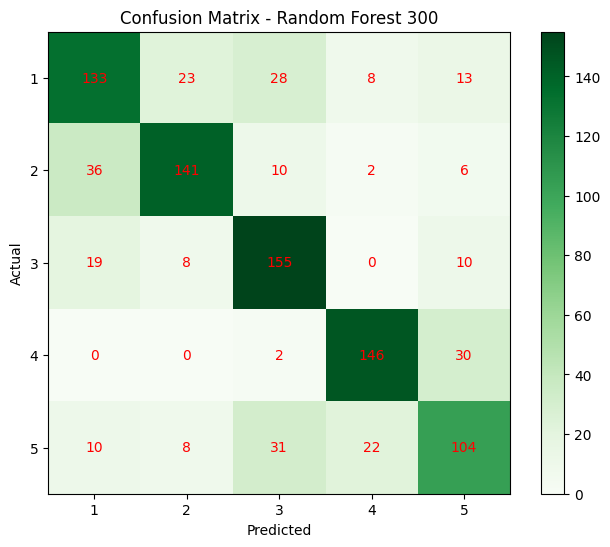

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1) Confusion Matrix
# =========================
rf_test = test_set.classify(rf_test2)
cm = rf_test.errorMatrix('class', 'classification')

# ดึง matrix มาเป็น numpy
conf_matrix = np.array(cm.getInfo())

# ❗ ตัด class 0 (background)
conf_matrix = conf_matrix[1:, 1:]

print('Confusion Matrix :\n', conf_matrix)
print('Overall Accuracy:', cm.accuracy().getInfo())
print('Kappa:', cm.kappa().getInfo())


# =========================
# 2) Producer's & User's Accuracy (ตัด class 0)
# =========================
producers_acc = np.array(cm.producersAccuracy().getInfo()).flatten()[1:]
users_acc = np.array(cm.consumersAccuracy().getInfo()).flatten()[1:]

print("\nProducer's Accuracy (Recall) per class:")
for i, val in enumerate(producers_acc, start=1):
    print(f"Class {i}: {val:.4f}")

print("\nUser's Accuracy (Precision) per class:")
for i, val in enumerate(users_acc, start=1):
    print(f"Class {i}: {val:.4f}")


# =========================
# 3) F1-score per class
# =========================
f1_scores = []

for i in range(len(producers_acc)):
    precision = users_acc[i]
    recall = producers_acc[i]

    if (precision + recall) == 0:
        f1 = 0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)

    f1_scores.append(f1)

f1_scores = np.array(f1_scores)

print("\nF1-score per class:")
for i, val in enumerate(f1_scores, start=1):
    print(f"Class {i}: {val:.4f}")


# =========================
# 4) Average F1
# =========================
macro_f1 = np.mean(f1_scores)

# weighted F1 (ใช้ matrix ที่ตัดแล้ว)
support = conf_matrix.sum(axis=1)
weighted_f1 = np.sum(f1_scores * support) / np.sum(support)

print("\nMacro F1-score:", round(macro_f1, 4))
print("Weighted F1-score:", round(weighted_f1, 4))


# =========================
# Confusion Matrix (ไม่มี class 0)
# =========================
plt.figure(figsize=(8,6))
plt.imshow(conf_matrix, cmap='Greens')
plt.title("Confusion Matrix - Random Forest 300")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

# กำหนด labels ให้แกน x,y เป็นคลาสจริง 1,2,3,4,5
classes = [1, 2, 3, 4, 5]  # class จริง
plt.xticks(ticks=range(len(classes)), labels=classes)
plt.yticks(ticks=range(len(classes)), labels=classes)

# ใส่ตัวเลขในช่อง
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j],
                 ha='center', va='center', color='red')

plt.show()

Confusion Matrix :
 [[128  25  28   8  16]
 [ 34 142   9   2   8]
 [ 22   7 147   0  16]
 [  0   0   2 146  30]
 [ 11   7  30  22 105]]
Overall Accuracy: 0.7068783068783069
Kappa: 0.6333690022325743

Producer's Accuracy (Recall) per class:
Class 1: 0.6244
Class 2: 0.7282
Class 3: 0.7656
Class 4: 0.8202
Class 5: 0.6000

User's Accuracy (Precision) per class:
Class 1: 0.6564
Class 2: 0.7845
Class 3: 0.6806
Class 4: 0.8202
Class 5: 0.6000

F1-score per class:
Class 1: 0.6400
Class 2: 0.7553
Class 3: 0.7206
Class 4: 0.8202
Class 5: 0.6000

Macro F1-score: 0.7072
Weighted F1-score: 0.7067


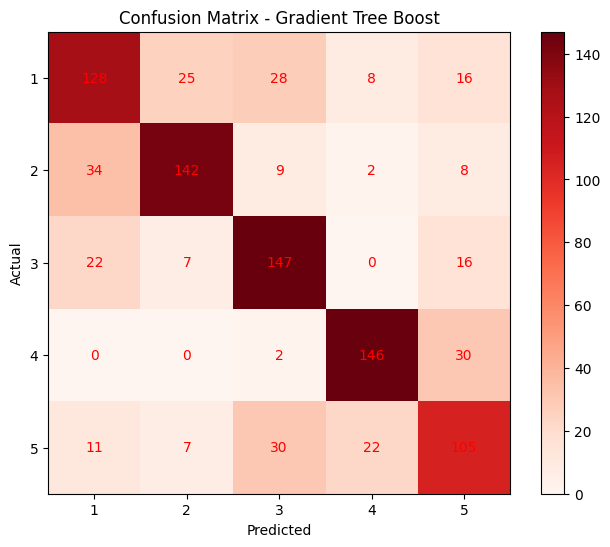

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1) Confusion Matrix
# =========================
rf_test = test_set.classify(gtb)
cm = rf_test.errorMatrix('class', 'classification')

# ดึง matrix มาเป็น numpy
conf_matrix = np.array(cm.getInfo())

# ❗ ตัด class 0 (background)
conf_matrix = conf_matrix[1:, 1:]

print('Confusion Matrix :\n', conf_matrix)
print('Overall Accuracy:', cm.accuracy().getInfo())
print('Kappa:', cm.kappa().getInfo())


# =========================
# 2) Producer's & User's Accuracy (ตัด class 0)
# =========================
producers_acc = np.array(cm.producersAccuracy().getInfo()).flatten()[1:]
users_acc = np.array(cm.consumersAccuracy().getInfo()).flatten()[1:]

print("\nProducer's Accuracy (Recall) per class:")
for i, val in enumerate(producers_acc, start=1):
    print(f"Class {i}: {val:.4f}")

print("\nUser's Accuracy (Precision) per class:")
for i, val in enumerate(users_acc, start=1):
    print(f"Class {i}: {val:.4f}")


# =========================
# 3) F1-score per class
# =========================
f1_scores = []

for i in range(len(producers_acc)):
    precision = users_acc[i]
    recall = producers_acc[i]

    if (precision + recall) == 0:
        f1 = 0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)

    f1_scores.append(f1)

f1_scores = np.array(f1_scores)

print("\nF1-score per class:")
for i, val in enumerate(f1_scores, start=1):
    print(f"Class {i}: {val:.4f}")


# =========================
# 4) Average F1
# =========================
macro_f1 = np.mean(f1_scores)

# weighted F1 (ใช้ matrix ที่ตัดแล้ว)
support = conf_matrix.sum(axis=1)
weighted_f1 = np.sum(f1_scores * support) / np.sum(support)

print("\nMacro F1-score:", round(macro_f1, 4))
print("Weighted F1-score:", round(weighted_f1, 4))


# =========================
# Confusion Matrix (ไม่มี class 0)
# =========================
plt.figure(figsize=(8,6))
plt.imshow(conf_matrix, cmap='Reds')
plt.title("Confusion Matrix - Gradient Tree Boost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

# กำหนด labels ให้แกน x,y เป็นคลาสจริง 1,2,3,4,5
classes = [1, 2, 3, 4, 5]  # class จริง
plt.xticks(ticks=range(len(classes)), labels=classes)
plt.yticks(ticks=range(len(classes)), labels=classes)

# ใส่ตัวเลขในช่อง
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j],
                 ha='center', va='center', color='red')

plt.show()

Feature Importance:
{'B11': 307095.175245743, 'B2': 190385.18087840214, 'B3': 136813.24080017017, 'B4': 194270.19787704202, 'B8': 149215.36112497593, 'NDBI': 168768.00526542854, 'NDVI': 194958.0228142383, 'NDWI': 187651.7568856403}


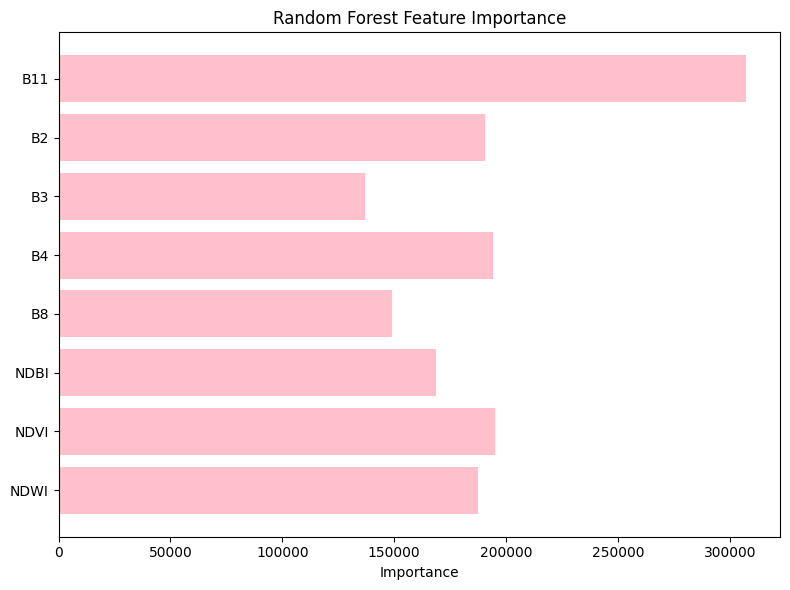

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Feature Importance
# =========================
importance = gtb.explain().get('importance')
importance_dict = importance.getInfo()
# แยกชื่อ feature กับค่า importance
features = list(importance_dict.keys())
values = list(importance_dict.values())

print('Feature Importance:')
print(importance.getInfo())
# =========================
# Plot Feature Importance
# =========================
plt.figure(figsize=(8,6))
plt.barh(features, values, color='pink')  # bar แนวนอน
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()  # ให้ค่าที่สำคัญสุดอยู่ด้านบน
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

In [69]:
# =========================
# Uncertainty Map (จาก RF)
# =========================

# สร้าง probability ของแต่ละ class
prob = image.select(bands).classify(
    rf.setOutputMode('MULTIPROBABILITY')  # หรือ gbt.setOutputMode('MULTIPROBABILITY')
)

# หาค่าความมั่นใจสูงสุดของแต่ละ pixel
max_prob = prob.arrayReduce(ee.Reducer.max(), [0]).arrayGet([0])  # แปลงเป็น single-band

# คำนวณความไม่แน่นอน
uncertainty = ee.Image(1).subtract(max_prob)

# =========================
# สร้าง Map object ใหม่
# =========================
Map_uncertainty = geemap.Map()  # Map object ใหม่
Map_uncertainty.centerObject(roi, 8)

# เพิ่ม layer Uncertainty
Map_uncertainty.addLayer(uncertainty, {
    'min': 0,
    'max': 1,
    'palette': ['white', 'red']  # ขาว = มั่นใจ, แดง = ไม่มั่นใจ
}, 'Uncertainty Map')

# แสดง Map
Map_uncertainty

Map(center=[12.87622230139344, 102.13202401595468], controls=(WidgetControl(options=['position', 'transparent_…

# Test ชวนคิด

In [61]:
#ลองเพิ่ม training data เป็นสองเท่า

# =========================
# Task 1: Sampling + Train/Test Split
# =========================
samples = image.addBands(lc_remap).stratifiedSample(
    numPoints=2000,
    classBand='class',
    region=roi,
    scale=10,
    geometries=True
)

# split 80/20
withRandom = samples.randomColumn('random')

train_set = withRandom.filter('random < 0.8')
test_set = withRandom.filter('random >= 0.8')

print('Train size:', train_set.size().getInfo())
print('Test size:', test_set.size().getInfo())

# =========================
# Task 2: Random Forest
# =========================
rf_2 = ee.Classifier.smileRandomForest(100).train(
    features=train_set,
    classProperty='class',
    inputProperties=bands
)

rf_classified = image.select(bands).classify(rf_2)

Map.addLayer(rf_classified, {
    'min': 1,
    'max': 5,
    'palette': ['yellow','green','red','blue','gray']
}, 'RF Classification')

Map

Train size: 8025
Test size: 1975


Map(center=[12.87622230139344, 102.13202401595468], controls=(WidgetControl(options=['position', 'transparent_…

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1) Confusion Matrix
# =========================
rf_test = test_set.classify(rf_2)
cm = rf_test.errorMatrix('class', 'classification')

# ดึง matrix มาเป็น numpy
conf_matrix = np.array(cm.getInfo())

#  ตัด class 0 (background)
conf_matrix = conf_matrix[1:, 1:]

print('Confusion Matrix :\n', conf_matrix)
print('Overall Accuracy:', cm.accuracy().getInfo())
print('Kappa:', cm.kappa().getInfo())


Confusion Matrix :
 [[242  55  48   7  31]
 [ 73 275  18   3  18]
 [ 47   8 310   1  41]
 [  2   2   3 305  69]
 [ 30  12  44  67 264]]
Overall Accuracy: 0.7068354430379746
Kappa: 0.6333708878161886
